# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1 : Calabozo Nicolás
- Alumno 2 : Lapolla Martín

##0. Introducción a la Etapa 2: Entrenamiento y Evaluación de Modelos


En esta etapa, el objetivo principal es desarrollar un sistema de clasificación capaz de identificar 70 razas de perros. El flujo de trabajo se divide en cuatro pilares fundamentales:

1.  **Análisis y Balanceo de Datos:** Exploramos la distribución original del dataset. Como se observó un desbalance (algunas razas con pocas imágenes), aplicamos técnicas de **Data Augmentation** (rotaciones, cambios de brillo, etc.) utilizando la librería `albumentations` para asegurar que cada clase tenga al menos 200 muestras para el entrenamiento.

2.  **Modelo A (Transfer Learning):** Realizamos un *fine-tuning* de **ResNet18**, una arquitectura probada y pre-entrenada en ImageNet. Esto nos permite aprovechar descriptores visuales genéricos y adaptarlos específicamente a las características de las razas caninas.

3.  **Modelo B (CNN Propia):** Diseñamos y entrenamos una red neuronal convolucional desde cero (*custom CNN*). Este enfoque nos permite experimentar con una arquitectura propia y comparar su desempeño contra el modelo pre-entrenado.

4.  **Estudio Comparativo:** Finalmente, evaluamos ambos modelos mediante métricas de clasificación (Accuracy, Precision, Recall, F1-Score), matrices de confusión, y un análisis de falsos positivos y falsos negativos, para identificar cuáles son las razas más difíciles de distinguir.

## 1. Preparación del Entorno de Trabajo

### 1.1 Clonación del Repositorio y Descarga de Modelos

In [ ]:
%cd /content
!rm -rf proyecto
REPO_URL = "https://github.com/NicolasCalabozo/tuia-dog-recognition-app"
RAMA = "calabozo-lapolla"
!git clone -b $RAMA $REPO_URL proyecto
%cd proyecto

/content
Cloning into 'proyecto'...
remote: Enumerating objects: 227, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 227 (delta 96), reused 86 (delta 78), pack-reused 108 (from 1)
Receiving objects: 100% (227/227), 8.43 MiB | 9.56 MiB/s, done.
Resolving deltas: 100% (141/141), done.
/content/proyecto


In [ ]:
!gdown --folder 1ZT4FBqUjQwCUnFmLYLl5JPPcp4Y5NwmL -O /content/proyecto/models

Retrieving folder contents
Processing file 1Tpu8KJhsVwfQnLkamTnpSq5gDjVMbd9K cnn_custom_history.json
Processing file 1GzFhNlZDyN2IRezj1dO17c-fUl6hW7VA cnn_custom_metrics.json
Processing file 1VvnqvchSVzkdreVOv9b0VUXnD1TvKl92 cnn_custom.pth
Processing file 1wChLAwTpvHfqG_oE7Te8N7LUpOPp6JZL resnet18_finetuned_history.json
Processing file 1bI0UqOkneM7xZ0UUPIJ7EVwtVkUuthAg resnet18_finetuned_metrics.json
Processing file 1M-5JEyc0F0TGr9KACHMafham2xCXFHFd resnet18_finetuned.pth
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Tpu8KJhsVwfQnLkamTnpSq5gDjVMbd9K
To: /content/proyecto/models/cnn_custom_history.json
100% 6.79k/6.79k [00:00<00:00, 31.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GzFhNlZDyN2IRezj1dO17c-fUl6hW7VA
To: /content/proyecto/models/cnn_custom_metrics.json
100% 1.83M/1.83M [00:00<00:00, 55.1MB/s]
Downloading...
From (original): https://drive.google.com/u

### 1.2 Instalación de Dependencias e Importación de Módulos



In [ ]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations -qq

In [ ]:
!pip install onnxruntime ultralytics -qq

In [ ]:
from PIL import Image
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter
import json
import pandas as pd
import albumentations as A
import numpy as np
import os
import sys
from pathlib import Path
from IPython.display import display, HTML
import seaborn as sns

### 1.3 Configuracion del entorno

In [ ]:
os.environ["USE_PGVECTOR"] = "false"
# Ajusta aca cualquier otra variable (IMAGE_SIZE, EMBEDDING_DIM, paths, etc.)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())



dataset_path: data/dataset
GPU disponible: True


In [ ]:
from lib.bootstrap import build_classifier

classifier = build_classifier(settings)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### 1.4 Descarga del dataset

In [ ]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Dataset disponible en /content/proyecto/data/dataset
dogs.csv  test	train  valid


In [ ]:
#Correción de nombre en carpeta de Test
!mv "data/dataset/valid/American  Spaniel" "data/dataset/valid/American Spaniel"

## 2. Analisis del dataset

### 2.1 Carga y Configuración del Pipeline de Datos

Antes de profundizar en la distribución de las clases, es fundamental entender cómo se estructuran y procesan los datos para el consumo del modelo:

* Utilizamos la clase 'datasets.ImageFolder' de PyTorch, que mapea automáticamente la estructura de carpetas (donde cada subcarpeta es una raza) a etiquetas numéricas. El constructor de la clase cuenta con un argumento 'transform' el cual permite pasarle un pipeline de preprocesamiento para asegurar que todas nuestras imágenes posean la misma dimensión (3 , 224 , 224) y para que los canales RGB esten normalizados según el la media y desvío estandar de ImageNet, asegurando así la compatibilidad con los modelos preentrenados.
* Hemos definido un batch size de 32, teniendo en cuenta las restricciones de tiempo de uso, y VRAM de la placa de video proporcionada por Google Colab (Nvidia T4)
* A partir del batch size antes mencionado, utilizamos la clase 'datasets.Dataloader' para cargar el total de las imágenes en un objeto iterable por lotes. El argumento Shuffle, en entrenamiento, es de suma importancia ya que permite aleatorizar las imágenes dentro de los lotes, lo que previene que el modelo aprenda patrones sesgados de raza al tomar, por ejemplo, lotes completos de una misma raza, o aprender el orden específico de aparición o secuencia de las mismas, logrando así una mejor generalización.

In [ ]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

data_dir = os.getenv("DATASET_PATH", "/content/proyecto/data/dataset")
print(f"Carpeta contenedora del dataset: {data_dir}")
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'train'), transform=preprocess)
valid_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'valid'), transform=preprocess)
test_dataset  = datasets.ImageFolder(root=os.path.join(data_dir, 'test'), transform=preprocess)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Total de clases detectadas: {len(train_dataset.classes)}")
print(f"Total de imágenes para entrenar: {len(train_dataset)}")

Carpeta contenedora del dataset: /content/proyecto/data/dataset
Total de clases detectadas: 70
Total de imágenes para entrenar: 7946


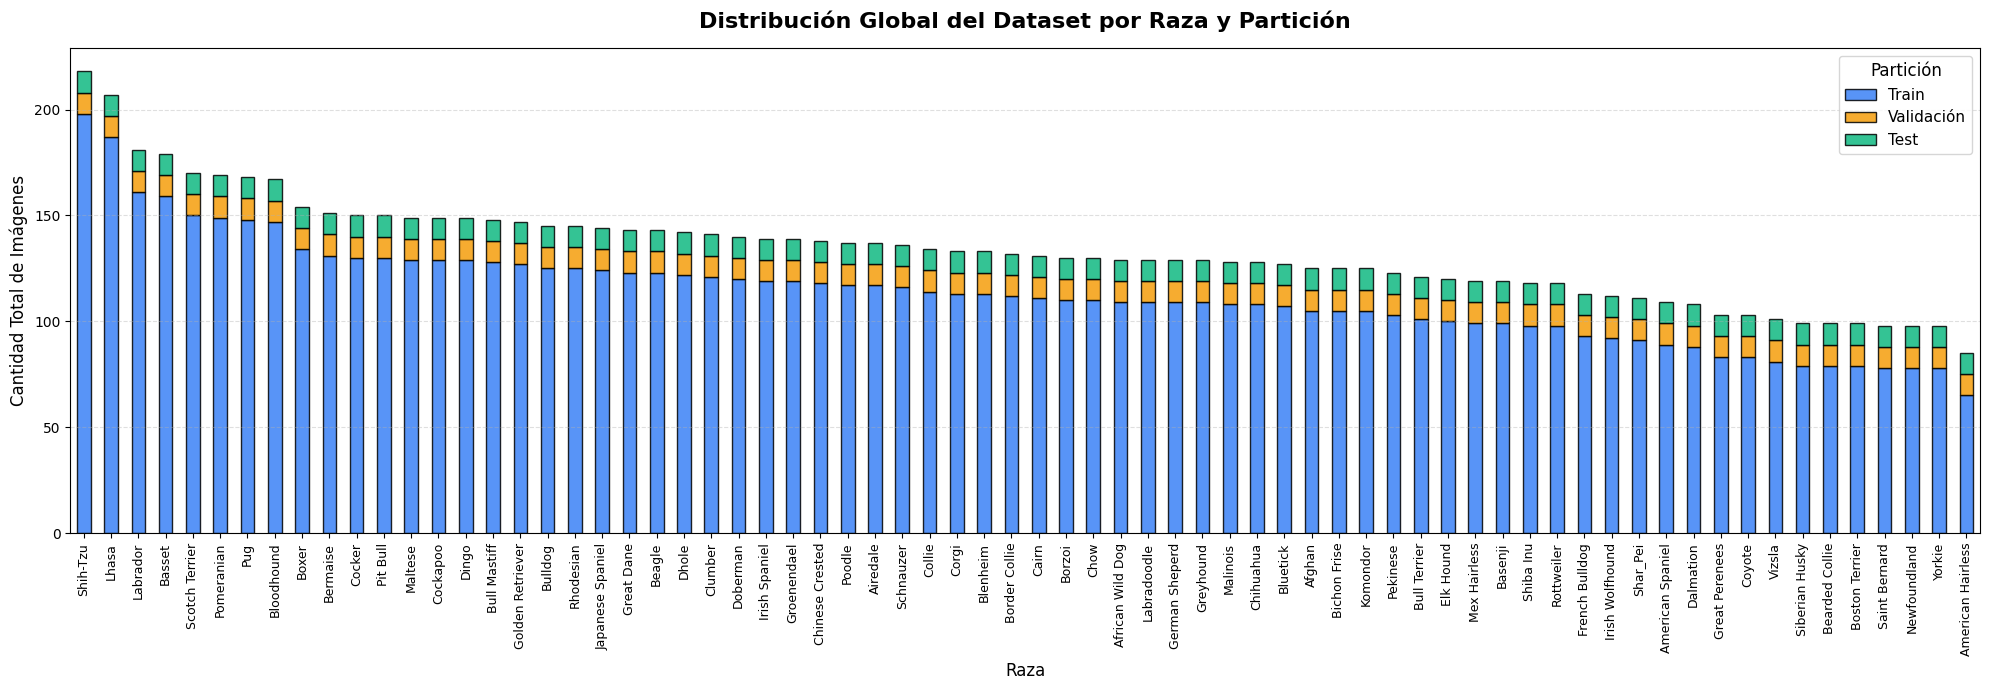

In [ ]:
# Creamos el diccionario de mapeo ID -> Nombre de la raza
id_a_raza = {id_num: nombre for nombre, id_num in train_dataset.class_to_idx.items()}

#Contamos las etiquetas de cada partición
conteo_train = Counter(train_dataset.targets)
conteo_val = Counter(valid_dataset.targets)
conteo_test = Counter(test_dataset.targets)

# Consolidamos todo en un DataFrame
df_dist = pd.DataFrame({
    'Train': conteo_train,
    'Validación': conteo_val,
    'Test': conteo_test
    })

# Reemplazamos el índice numérico por los nombres usando nuestro id_a_raza
df_dist.index = [id_a_raza[i] for i in df_dist.index]

# Ordenamos de mayor a menor por total de imágenes
df_dist['Total'] = df_dist.sum(axis=1)
df_dist = df_dist.sort_values(by='Total', ascending=False)
df_dist = df_dist.drop(columns=['Total'])

#Graficamos
colores = ['#3b82f6', '#f59e0b', '#10b981']
plt.figure(figsize=(20, 7))

df_dist.plot(kind='bar', stacked=True, ax=plt.gca(), color=colores, edgecolor='black', alpha=0.85)

plt.title('Distribución Global del Dataset por Raza y Partición', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Raza', fontsize=12)
plt.ylabel('Cantidad Total de Imágenes', fontsize=12)

plt.xticks(rotation=90, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Partición', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

Basado en la distribución de clases, se observan las siguientes características en el conjunto de entrenamiento original:

*   **Clases Mayoritarias:** Las razas con mayor representación son **Shih-Tzu** (198 imágenes), **Lhasa** (187 imágenes) y **Labrador** (161 imágenes).
*   **Clases Minoritarias:** Las razas con menor cantidad de muestras iniciales son **American Hairless** (65 imágenes), **Yorkie** (78 imágenes) y **Saint Bernard** (78 imágenes).

Este desbalance de clases nos da pie a realizar un proceso de data augmentation para poder mitigar sesgos a la hora de entrenar a nuestros modelos.

A continuación verificaremos la cantidad de imagenes por clase en los conjuntos de Test y Validación

In [ ]:
#Si tengo la misma cantidad de imagenes para cada raza, un unique debería retornar un unico elemento
cantidades_unicas_test = df_dist['Test'].unique()
cantidades_unicas_valid = df_dist['Validación'].unique()

if len(cantidades_unicas_test) == 1:
  print(f'El conjunto de test tiene {cantidades_unicas_test} imagenes por Raza')
  print(f'El conjunto de validación tiene {cantidades_unicas_valid} imagenes por Raza')


El conjunto de test tiene [10] imagenes por Raza
El conjunto de validación tiene [10] imagenes por Raza


Para poder adentrarnos un poco en el dataset que estaremos trabajando, haremos una observación inicial de las imágenes que utilizaremos para nuestro entrenamiento

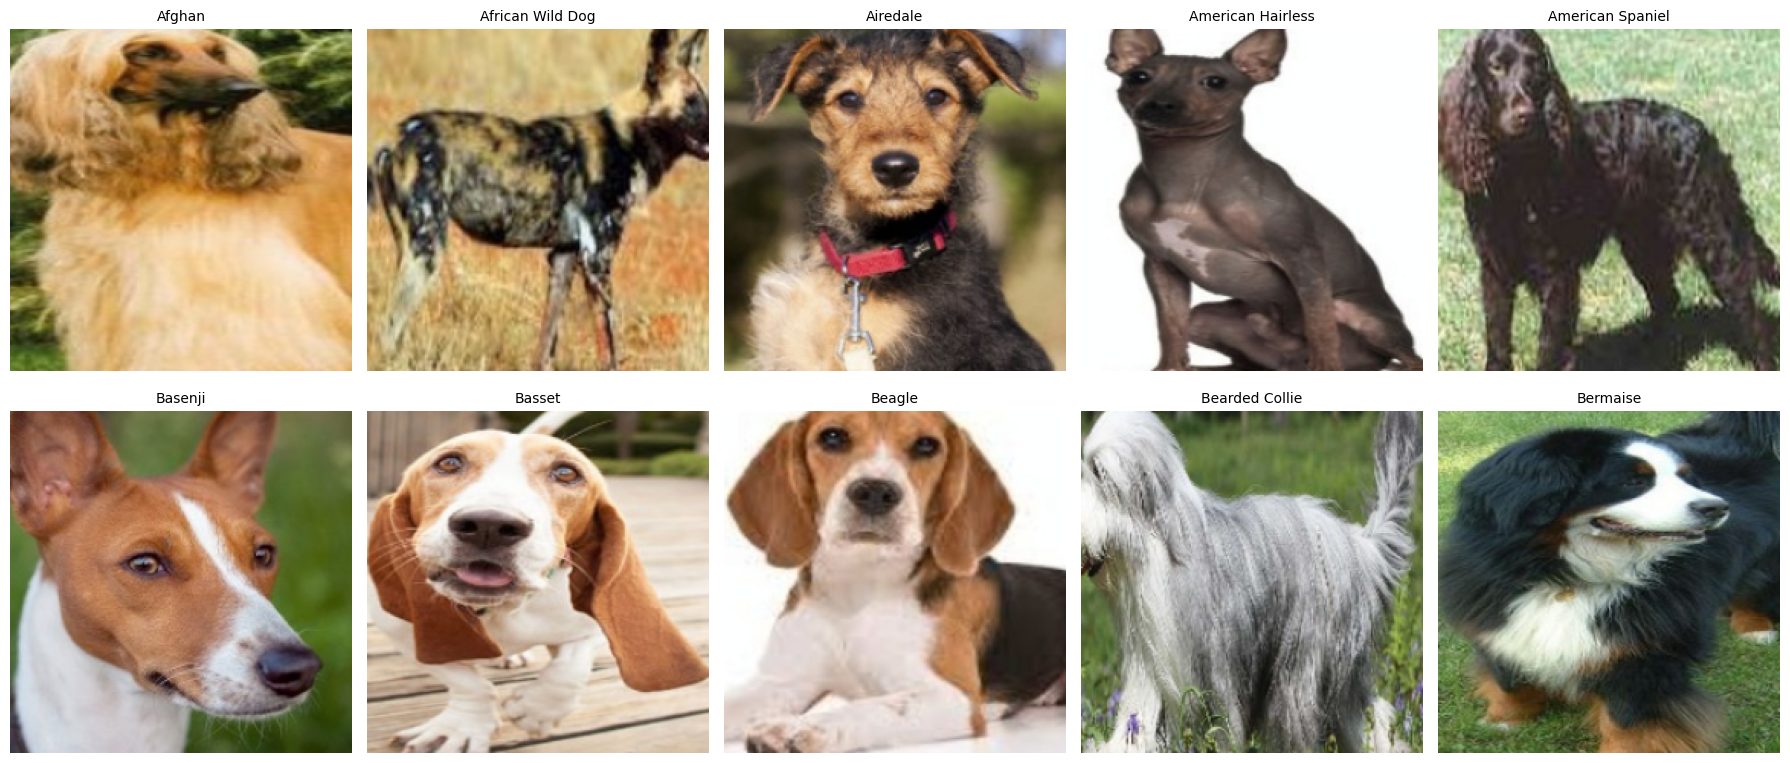

In [ ]:
imagenes_a_mostrar = {}
for imagen, etiqueta in train_dataset:
    if etiqueta not in imagenes_a_mostrar:
        imagenes_a_mostrar[etiqueta] = imagen
    if len(imagenes_a_mostrar) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for idx, (etiqueta, imagen) in enumerate(imagenes_a_mostrar.items()):
    nombre_raza = id_a_raza[etiqueta]

    img_para_mostrar = imagen.permute(1, 2, 0).numpy()

    img_para_mostrar = std * img_para_mostrar + mean
    img_para_mostrar = np.clip(img_para_mostrar, 0, 1)

    axes[idx].imshow(img_para_mostrar)
    axes[idx].set_title(nombre_raza, fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Podemos observar, de manera preliminar, que hay mucha variedad en la composición de las imágenes, incluyendo tomas de cuerpo completo y planos de rasgos faciales. Esto puede ser visto como un desafío y, a su vez, como una ventaja. Si esta distribución de imágenes se mantiene para todos las las razas, es decir, tenemos planos frontales, laterales, de cuerpo completo y con foco en el rostro, vamos a estar forzando a nuestros modelos a aprender la representación completa de la raza. Teniendo en cuenta el funcionamiento de las capas convolucionales en la etapa de entrenamiento, el modelo, en teoría, será capaz de aprender desde descriptores generales como son las siluetas de cada raza, hasta descriptores locales muy específicos como pueden ser rasgos faciales, texturas de pelaje, entre otros.

## 3. Data Augmentation

Como mencionamos previamente en el análisis del Dataset, se realizará un proceso de data augmentation para lograr balancear la cantidad de imagenes por clase en el conjunto de entrenamiento y así evitar predicciones sesgadas hacia las clases mayoritarias. Para ello nos valemos de la libería Albumentations que nos permite hacer transformaciones geométricas, de color,y de desenfoque.

In [ ]:
augmenter_albumentations = A.Compose([
    # Realiza una rotación horizontal
    A.HorizontalFlip(p=0.5),
    # Gira la imagen 15 grados
    # Safe rotate asegura que la enteridad de la imagen quede contenida dentro de una matriz del tamaño original
    # y que no se recorten accidentalmente partes de la foto al hacer la transformación
    A.SafeRotate(limit=15, p=0.8),
    # Cambia el brillo, contraste, saturación, intensidad y tono
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.8),
    # Convierte a escala de grises
    A.ToGray(p=0.2),
    # Aplica un filtro de ruido gaussiano
    A.GaussianBlur(blur_limit=(3, 5), p=0.3)
])

El objetivo de realizar este tipo de data augmentation no es solamente aumentar el tamaño del dataset en sí, si no, mejorar la capacidad de generalización del modelo introduciendo nuevas formas de interpretar a una misma raza.

Las transformaciones geométricas 'SafeRotate' y 'HorizontalFlip' fuerzan al modelo a reconocer, por ejemplo, la silueta de una raza en específico sin tener en cuenta la orientación de la misma. Esto lo hace mucho más robusto a la hora de evaluar nuevas fotos, ya que no podemos asegurar el ángulo en que fue tomada ni la orientación del perro en la misma.

Las transformaciones de color, saturación, tono y brillo ('ColorJitter') en cambio, fuerzan a nuestro modelo a no depender de tan fuertemente de la información cromática, permitiendo que este se enfoque más en texturas y rasgos específicos de la raza. Ante nuevas fotos, esto nos permite mitigar, por ejemplo, las imagenes con flash, que contienen exceso de brillo o su caso contrario, imagenes con poca iluminación o mala exposición.

Finalmente las transformaciones de desenfoque, como es 'GaussianBlur', introducen ruido en la imagen de manera aleatoria, haciendo que nuestro modelo sea más robusto ante fotos de baja calidad, mal enfocadas, con movimiento, o con ruido digital.

Una vez definidas las transformaciones, procedemos a utilizarlas para generar imágenes para cada Raza de nuestro dataset. Priorizamos mantener las imágenes originales y generar las faltantes hasta llegar a 200 imagenes por clase.

In [ ]:
def data_augmentation(directorio_train, objetivo=200):
    print("Iniciando balanceo de clases")

    for raza in os.listdir(directorio_train):
        ruta_raza = os.path.join(directorio_train, raza)
        if not os.path.isdir(ruta_raza): continue

        archivos = [f for f in os.listdir(ruta_raza) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        cantidad_actual = len(archivos)

        if cantidad_actual < objetivo:
            faltantes = objetivo - cantidad_actual
            print(f"{raza.ljust(25)}: Faltan generar {faltantes} imágenes.")

            for i in range(faltantes):
                archivo_base = random.choice(archivos)
                ruta_base = os.path.join(ruta_raza, archivo_base)

                try:
                    with Image.open(ruta_base) as img:
                        img_convertida = img.convert('RGB')

                        # Convertir imagen PIL a un Array de NumPy
                        img_array = np.array(img_convertida)

                        transformacion = augmenter_albumentations(image=img_array)
                        img_array_aumentado = transformacion['image']

                        # Convertir el Array modificado de vuelta a PIL
                        img_final = Image.fromarray(img_array_aumentado)


                        nuevo_nombre = f"aug_{i}_{archivo_base}"
                        ruta_nueva = os.path.join(ruta_raza, nuevo_nombre)
                        img_final.save(ruta_nueva, 'JPEG')

                except Exception as e:
                    print(f"Error procesando {archivo_base}: {e}")

    print("-" * 40)
    print("Proceso finalizado")

directorio_entrenamiento = 'data/dataset/train'
data_augmentation(directorio_entrenamiento, objetivo=200)

Iniciando balanceo de clases
Komondor                 : Faltan generar 95 imágenes.
Shiba Inu                : Faltan generar 102 imágenes.
Corgi                    : Faltan generar 87 imágenes.
Shar_Pei                 : Faltan generar 109 imágenes.
Airedale                 : Faltan generar 83 imágenes.
Bulldog                  : Faltan generar 75 imágenes.
Collie                   : Faltan generar 86 imágenes.
Bull Mastiff             : Faltan generar 72 imágenes.
Shih-Tzu                 : Faltan generar 2 imágenes.
Malinois                 : Faltan generar 92 imágenes.
Irish Wolfhound          : Faltan generar 108 imágenes.
Pekinese                 : Faltan generar 97 imágenes.
Groenendael              : Faltan generar 81 imágenes.
Rottweiler               : Faltan generar 102 imágenes.
French Bulldog           : Faltan generar 107 imágenes.
Irish Spaniel            : Faltan generar 81 imágenes.
Great Perenees           : Faltan generar 117 imágenes.
Greyhound                : Falt

## 4. Entrenamiento de Modelos

Una vez tenemos el Dataset normalizado y balanceado, podemos proceder al entrenamiento de los modelos.

### 4.1 Fine-tuning de ResNet18


Para el entrenamiento del modelo ResNet18 utilizamos los siguientes hiperparámetros:

* Learning Rate: 0.001
* Épocas: 100
* Scheduler: ReduceLROnPlateau con Paciencia 5 y factor de reducción por defecto de 0.1
* Optimizador: Adam
* Early Stopping: 15 épocas
* Batch Size: 32 imágenes

In [ ]:
# classifier.set_active_model("resnet18_finetuned")
# historia = classifier.train_classifier()

Iniciando entrenamiento en: cuda
Modelo activo: resnet18_finetuned

Clases detectadas : 70
Usando un batch size de: 32

Modelo Instanciado: resnet18_finetuned

Época 1/100
----------
Entrenamiento - Pérdida: 1.0255 Precisión: 0.7132
Validacion - Pérdida: 0.4556 Precisión: 0.8471
-> Mejora - Checkpoint guardado

Época 2/100
----------
Entrenamiento - Pérdida: 0.3475 Precisión: 0.8931
Validacion - Pérdida: 0.4352 Precisión: 0.8557
-> Mejora - Checkpoint guardado

Época 3/100
----------
Entrenamiento - Pérdida: 0.1989 Precisión: 0.9393
Validacion - Pérdida: 0.3498 Precisión: 0.8886
-> Mejora - Checkpoint guardado

Época 4/100
----------
Entrenamiento - Pérdida: 0.1354 Precisión: 0.9584
Validacion - Pérdida: 0.4084 Precisión: 0.8714
-> Sin mejoras en validación. Paciencia Early Stopping: 1/15

Época 5/100
----------
Entrenamiento - Pérdida: 0.0982 Precisión: 0.9700
Validacion - Pérdida: 0.4005 Precisión: 0.8800
-> Sin mejoras en validación. Paciencia Early Stopping: 2/15

Época 6/100
-----

Observando la salida de nuestro entrenamiento podemos darnos cuenta rápidamente que el modelo puede estar sobreajustado ya que llega a prácticamente un accuracy en Train de 1.0 y una pérdida de prácticamente 0 en la Época 13. Lo mismo ocurre con el accuracy y la pérdida en validación, cuyos valores empiezan a oscilar a partir de la misma época.

En tanto al scheduler, como nuestra paciencia es de 5 épocas sin mejora, se disparó en la época 8, pasando de 0.001 a 0.001 (learning rate) * 0.1 (factor de reducción) = 0.0001 esto nos permite descender de manera más suave por el gradiente y no saltar los posibles valores mínimos de pérdida en validación. Ocurre nuevamente en la época 31, bajando el learning rate a 0.00001, dando paso a una mejora en la época 32. Este comportamiento se mantiene siempre y cuando hayan 5 épocas sin mejora, bajando un orden de magnitud de forma 0.001 x 10^n (con n perteneciente a los enteros negativos) por cada vez que este se dispare.

La perdida en validación mínima se da en la época 45, donde empieza a dispararse nuestro mecanismo de early stopping, que compara la pérdida de la mejor época contra las siguientes. La oscilación se mantiene lo suficiente como para cortar el entrenamiento en la época 60.

Obtenemos nuestro mejor modelo en la época 45, con un tiempo total de entrenamiento de 42m 4s.



In [ ]:
classifier.set_active_model("resnet18_finetuned")
metrics_a = classifier.evaluate_classifier()

Evaluando modelo 'resnet18_finetuned' sobre 700 imágenes
Métricas guardadas exitosamente en: output/resnet18_finetuned_metrics.json


In [ ]:
with open("/content/proyecto/output/resnet18_finetuned_metrics.json", 'r') as archivo:
    datos = json.load(archivo)

In [ ]:
conf_matrix_r18 = datos.pop('confusion_matrix')
clases = datos.pop('classes')
y_true_r18 = datos.pop('y_true')
y_pred_r18 = datos.pop('y_probs')

In [ ]:
df_r18 = pd.DataFrame([datos])
df_r18_t = pd.DataFrame.from_dict(datos, orient='index', columns=['Resnet18'])
df_r18_t

,Resnet18
accuracy,0.97
precision,0.97
recall,0.97
specificity,1.00
f1,0.97


Podemos observar que nuestras métricas son muy elevadas, esto nos da a entender que nuestro modelo tiene gran capacidad de generalización, refutando que el modelo esté sobreajustado.

Tener una especificidad perfecta nos indica que nuestro modelo presenta una ausencia de falsos positivos, ya que es la única manera, interpretando la fórmula, que esto pase. Esto es una ilusión, ya que si analizamos clase por clase la matriz de confusión, podemos observar existencia de falsos positivos. Lo más probable es que se deba a un error de redondeo decimal a dos cifras y nuestra especificidad real sea mayor a 0.995, pero menor que 1.

El resto de las métricas apoyan esta teoría, ya que si nuestra especificidad fuese exactamente uno, al realizarse un promedio de especificidad de todas las clases, indicaría que ninguna tiene falsos positivos, a su vez indica que ninguna otra tiene falsos negativos, y el resto de las métricas tendrían que tener el valor de uno exacto.

Nuestras métricas, sin embargo, son excepcionalmente buenas ya que están basadas en los promedios de métricas por clase, también llamado promedio macro. Un F1-Score alto nos indica un muy buen balance entre precisión y recall, esto nos indica que nuestro modelo no está emitiendo en gran cantidad falsos positivos (precisión), ni está perdiendo verdaderos positivos (recall).

### 4.2 Curvas de entrenamiento y matriz de confusion (ResNet-18)


In [ ]:
def graficar_historial_entrenamiento(train_acc, val_acc, train_loss, val_loss, epoca_checkpoint=45):
    """
    Grafica las curvas de Accuracy y Pérdida para entrenamiento y validación.

    Parámetros:
    - train_acc: lista o array con el accuracy de entrenamiento por época.
    - val_acc: lista o array con el accuracy de validación por época.
    - train_loss: lista o array con la pérdida de entrenamiento por época.
    - val_loss: lista o array con la pérdida de validación por época.
    - checkpoint_epoch: época donde se guardó el mejor modelo. Si es None, no se grafica el punto de parada.
    """
    epocas = range(1, len(train_acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epocas, train_acc, 'b-', label='Accuracy Entrenamiento')
    plt.plot(epocas, val_acc, 'r-', label='Accuracy Validación')

    if epoca_checkpoint is not None:
        plt.axvline(x=epoca_checkpoint, color='g', linestyle='--', linewidth=2, label=f'Checkpoint (Ep {epoca_checkpoint})')

    plt.title('Accuracy de Train vs. Validación')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epocas, train_loss, 'b-', label='Pérdida Entrenamiento')
    plt.plot(epocas, val_loss, 'r-', label='Pérdida Validación')

    if epoca_checkpoint is not None:
        plt.axvline(x=epoca_checkpoint, color='g', linestyle='--', linewidth=2, label=f'Checkpoint (Ep {epoca_checkpoint})')

    plt.title('Pérdida de Train vs. Validación')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
with open("/content/proyecto/models/resnet18_finetuned_history.json", 'r') as archivo:
    datos_historia_r18 = json.load(archivo)

train_acc_r18 = datos_historia_r18['train_acc']
val_acc_r18 = datos_historia_r18['valid_acc']
train_loss_r18 = datos_historia_r18['train_loss']
val_loss_r18 = datos_historia_r18['valid_loss']

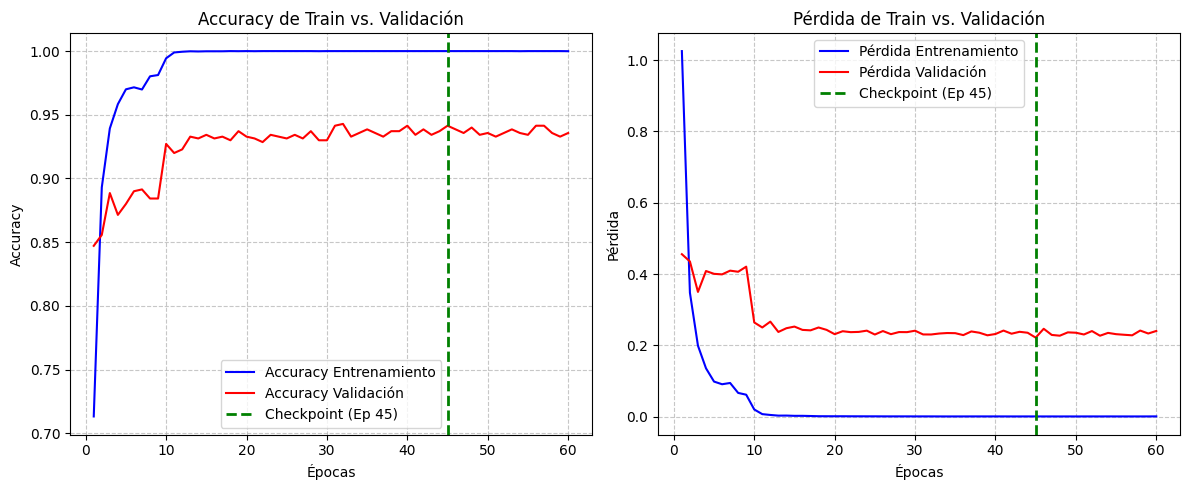

In [ ]:
graficar_historial_entrenamiento(train_acc_r18, val_acc_r18, train_loss_r18, val_loss_r18, 45)

Según lo observado en la etapa de entrenamiento, las gráficas de pérdida de entrenamiento vs. validación siguen lo explorado previamente. Podemos observar el estancamiento de las métricas a partir de la época 13 y evidenciar la acción del scheduler; la pérdida en validación se va estabilizando, lo que significa un descenso más suave por el gradiente en la búsqueda de un valor de pérdida mínimo.

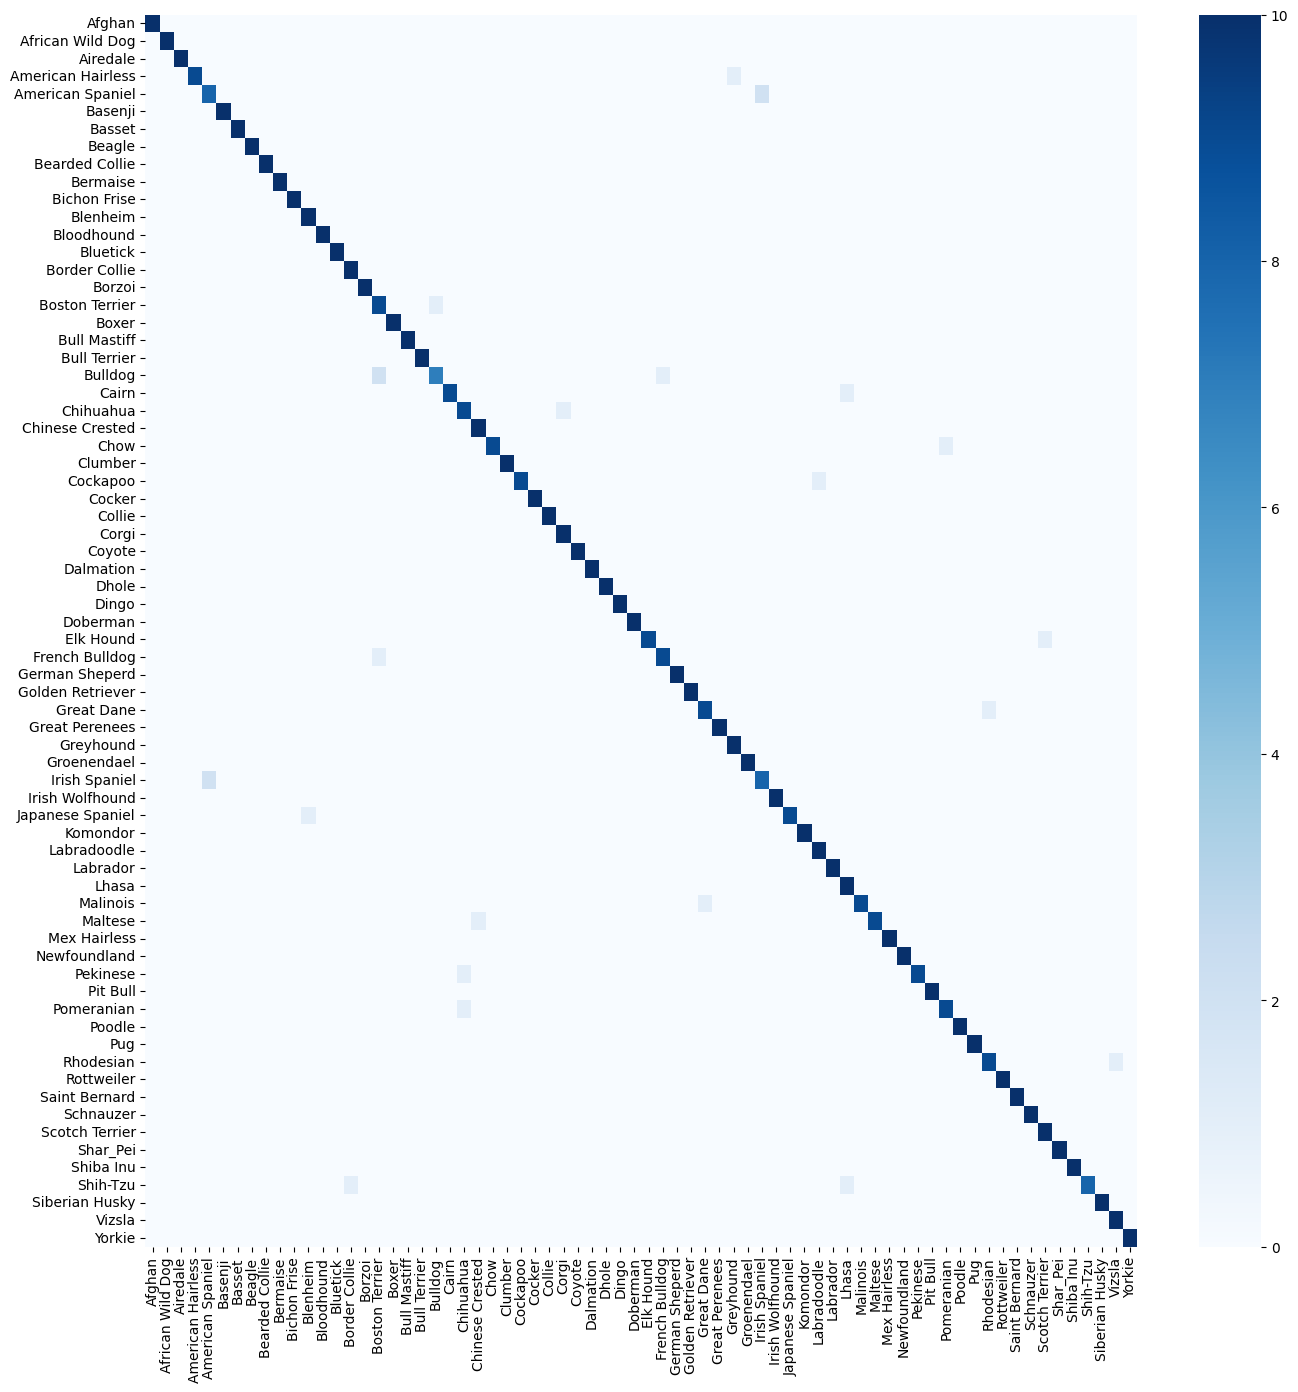

In [ ]:
df_cm_r18 = pd.DataFrame(conf_matrix_r18, index=clases, columns=clases)
plt.figure(figsize=(16, 16))
sns.heatmap(df_cm_r18, cmap='Blues')
plt.show()

Confirmamos lo observado en las métricas, estamos ante la presencia de algunos, aunque pocos, falsos positivos para las clases American Spaniel, Border Collie, Lhasa, entre otros.

## 4.3 Entrenamiento de CNN Propia


Para el entrenamiento de la CNN Propia utilizamos los mismos hiperparámetros utilizados con ResNet18

* Learning Rate: 0.001
* Épocas: 100
* Scheduler: ReduceLROnPlateau con Paciencia 5 y factor de reducción por defecto de 0.1
* Optimizador: Adam
* Early Stopping: 15 épocas
* Batch Size: 32 imágenes

In [ ]:
# classifier.set_active_model("cnn_custom")
# historia_cnn = classifier.train_classifier()

Iniciando entrenamiento en: cuda
Modelo activo: cnn_custom

Clases detectadas : 70
Usando un batch size de: 32

Modelo Instanciado: cnn_custom

Época 1/100
----------
Entrenamiento - Pérdida: 3.9379 Precisión: 0.0661
Validacion - Pérdida: 3.5444 Precisión: 0.0929
-> Mejora - Checkpoint guardado

Época 2/100
----------
Entrenamiento - Pérdida: 3.4583 Precisión: 0.1329
Validacion - Pérdida: 3.9475 Precisión: 0.1314
-> Sin mejoras en validación. Paciencia Early Stopping: 1/15

Época 3/100
----------
Entrenamiento - Pérdida: 3.1157 Precisión: 0.1972
Validacion - Pérdida: 2.7878 Precisión: 0.2457
-> Mejora - Checkpoint guardado

Época 4/100
----------
Entrenamiento - Pérdida: 2.7506 Precisión: 0.2675
Validacion - Pérdida: 2.5468 Precisión: 0.3171
-> Mejora - Checkpoint guardado

Época 5/100
----------
Entrenamiento - Pérdida: 2.3646 Precisión: 0.3569
Validacion - Pérdida: 2.5264 Precisión: 0.3457
-> Mejora - Checkpoint guardado

Época 6/100
----------
Entrenamiento - Pérdida: 1.9924 Precisi

Al observar los resultados del entrenamiento, resaltamos la utilidad del scheduler, en este caso es mucho más evidente el salto en métricas una vez se reduce el learning rate en la época 15, ya que logran dar un salto de +0.6 en accuracy y -0.15 de pérdida en validación en la época 17 relativo al último checkpoint. Esto vuelve a ocurrir en la época 26 donde comienzan a estabilizarse tanto el accuracy como la pérdida. El proceso termina en la época 60 luego de 15 épocas sin mejoras el el valór de perdida.

Obtenemos nuestro mejor modelo en la época 45, con un tiempo total de entrenamiento de 53m 37s.

In [ ]:
classifier.set_active_model("cnn_custom")
metrics_b = classifier.evaluate_classifier()

Evaluando modelo 'cnn_custom' sobre 700 imágenes
Métricas guardadas exitosamente en: output/cnn_custom_metrics.json


In [ ]:
with open("/content/proyecto/output/cnn_custom_metrics.json", 'r') as archivo:
    datos_cnn = json.load(archivo)

In [ ]:
conf_matrix_cnn = datos_cnn.pop('confusion_matrix')
clases_cnn = datos_cnn.pop('classes')
y_true_cnn = datos_cnn.pop('y_true')
y_pred_cnn = datos_cnn.pop('y_probs')

In [ ]:
df_cnn = pd.DataFrame([datos_cnn])
df_cnn_t = pd.DataFrame.from_dict(datos_cnn, orient='index', columns=['Custom CNN'])
df_cnn_t

,Custom CNN
accuracy,0.73
precision,0.75
recall,0.73
specificity,1.00
f1,0.73


Mediante estas métricas macro, podemos observar que nuestro modelo realmente ha aprendido de los datos. Su conocimiento es más superficial comparado a ResNet18, pero es lo suficientemente competente teniendo en cuenta las limitaciones técnicas.

De todas maneras, logra detectar el 73% de los verdaderos positivos, basandonos en el recall. Esto implica que un 27% de las detecciones fueron asignadas como falsos negativos relativos a otras clases.

La precisión nos indica que del total de las detecciones, solo el 75% son efectivamente verdaderos positivos, lo que indica que ha asignado un 25% de falsos positivos a otras razas.

Observamos otra problemática de la especificidad macro, al ser un problema multiclase, tenemos 700 imagenes en el conjunto de test de las cuales solo 10 pertenecen verdaderamente a una clase específica. Esto nos dá una posibilidad de 690 verdaderos negativos, lo que termina dominando el cálculo dando siempre valores cercanos a 1. Si tuviesemos una clase que, de manera desproporcionada, tuviese una cantidad significativa de falsos positivos para influenciar esta métrica, significaría que esa clase estaría acumulando la mayoría de las predicciones, volviendo a nuestro modelo obsoleto.

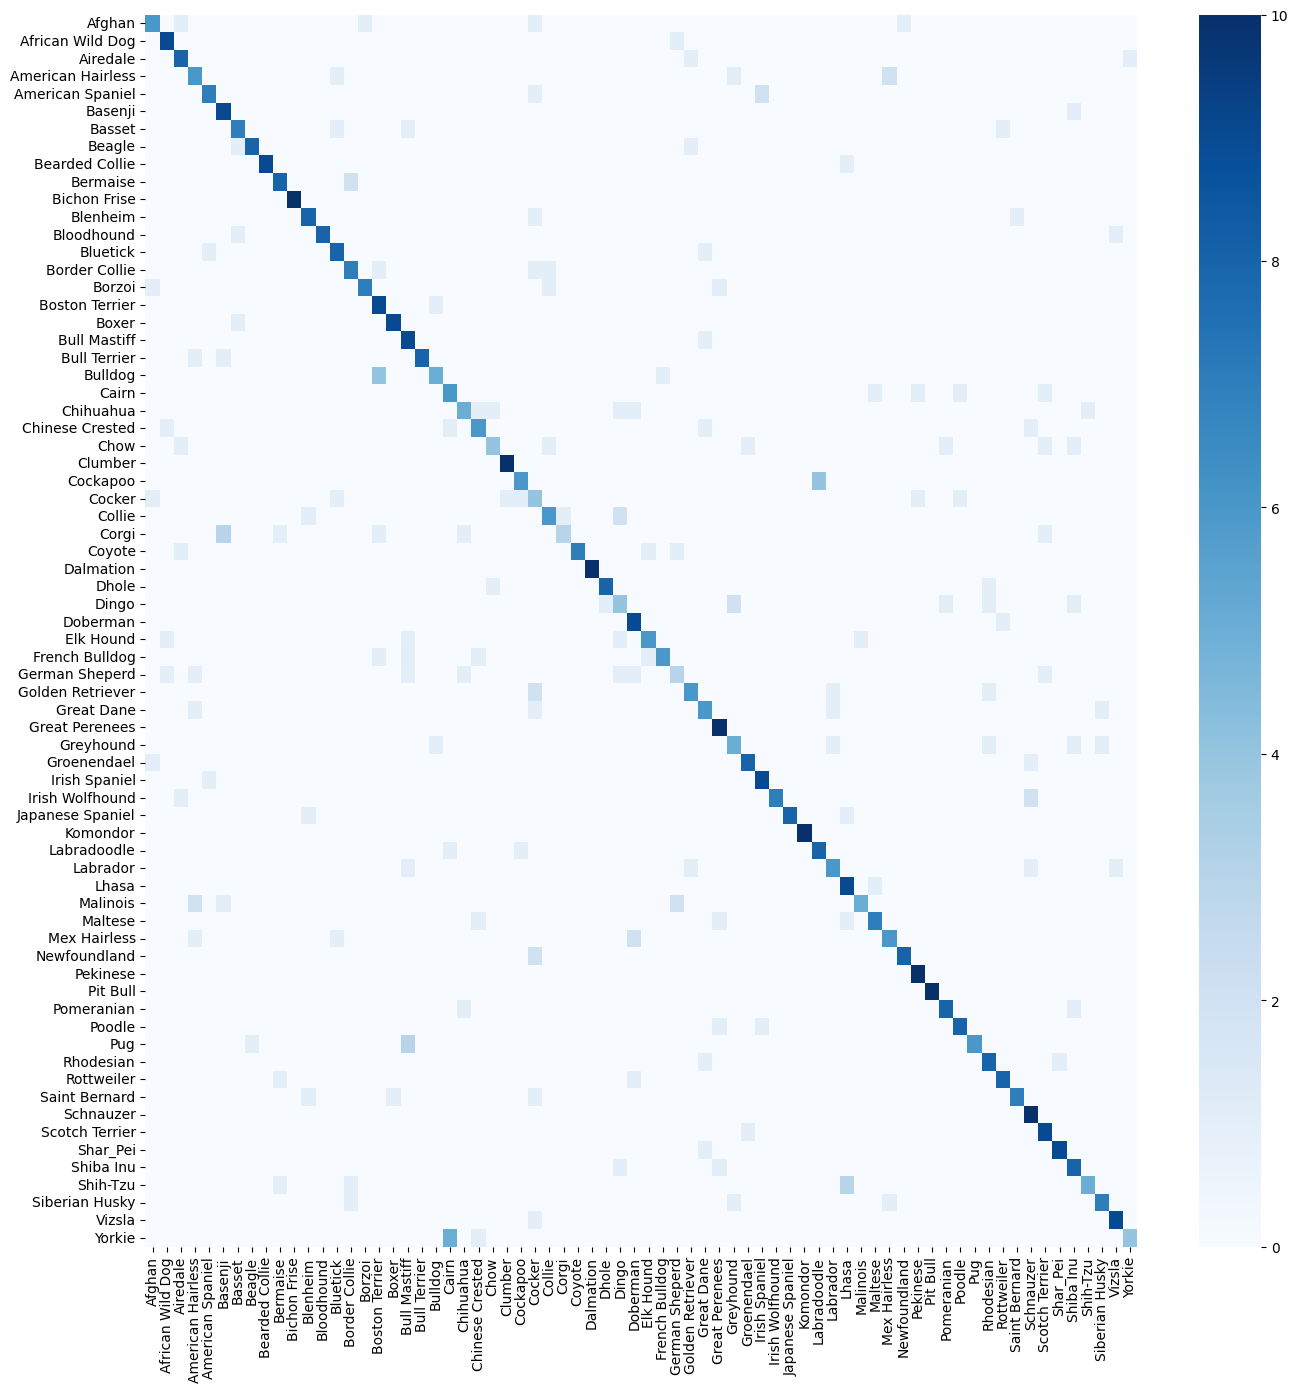

In [ ]:
plt.figure(figsize=(16, 16))
df_cm_cnn = pd.DataFrame(conf_matrix_cnn, index=clases, columns=clases)
sns.heatmap(df_cm_cnn, cmap='Blues')
plt.show()

Podemos observar que tenemos una mayor cantidad de falsos positivos en relación a la matriz de confusión de ResNet18. Lo destacable es que por una exploración visual, podemos darnos cuenta que la mayoría de estos falsos positivos provienen de razas con características similares. Podemos teorizar que el modelo es bueno para distinguir tamaño y textura básica, en caso de Cairn y Yorkie ambos son perros pequeños y peludos, o características fuertes como por ejemplo, razas de hocicos chatos como lo son el bulldog, bulldog francés y los mastines.

La causa de estas confusiones tienen que ver con lo mencionado previamente, a nuestra CNN le falta la complejidad suficiente como para poder reconocer patrones más fuertes y granulares en relación a las razas, sumado al dataset pequeño de donde extraer esos patrones.

In [ ]:
with open("/content/proyecto/models/cnn_custom_history.json", 'r') as archivo:
    datos_historia_cnn = json.load(archivo)

train_acc_cnn= datos_historia_cnn['train_acc']
val_acc_cnn = datos_historia_cnn['valid_acc']
train_loss_cnn = datos_historia_cnn['train_loss']
val_loss_cnn = datos_historia_cnn['valid_loss']

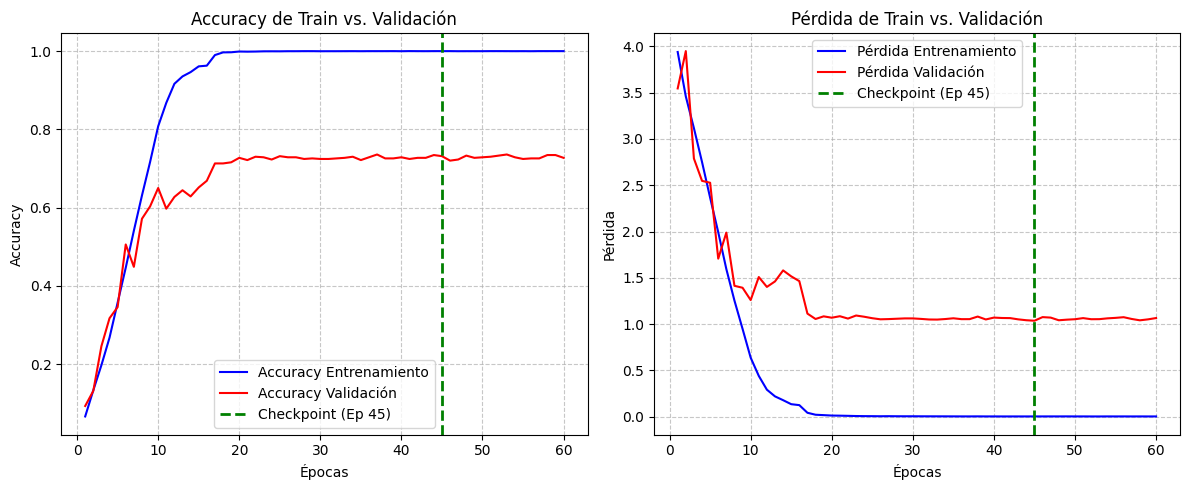

In [ ]:
graficar_historial_entrenamiento(train_acc_cnn, val_acc_cnn, train_loss_cnn, val_loss_cnn, 45)

Podemos observar patrones de comportamiento muy similares a los de ResNet18, con la diferencia que nuestro modelo Custom, al haber sido entrenado desde cero con un dataset relativamente pequeño, encuentra un piso de pérdida en validación de 1.0 - 1.1 y un techo de accuracy del 73% - 74%. Teniendo en cuenta las limitaciones temporales y de hardware, consideramos que hemos logrado alcanzar valores respetables. Comprendemos que mejorar estas métricas requeriría no solo complejizar la arquitectura de la CNN, aumentando la cantidad de parámetros y, a su vez, los costos computacionales, sino que también demandaría un incremento exponencial en el volumen de imágenes de entrenamiento para cada clase.


## 5. Estudio comparativo de los modelos

Una vez analizado cada modelo por su cuenta, podemos pasar al estudio comparativo entre ambos.

### 5.1 Comparación de Métricas

In [ ]:
df_metricas = pd.concat([df_cnn_t, df_r18_t], axis=1)
df_metricas['Delta'] = df_metricas['Custom CNN'] - df_metricas['Resnet18']
df_metricas.index = df_metricas.index.str.capitalize()

#Función para destacar el valor máximo de cada metrica entre los dos modelos
def destacar_modelos_y_delta(row):
    estilos = [''] * len(row)
    max_val = row[['Custom CNN', 'Resnet18']].max()

    for i, col in enumerate(row.index):
        if col in ['Custom CNN', 'Resnet18']:
            if row[col] == max_val:
                estilos[i] = 'font-weight: bold; color: #000000;'
            else:
                estilos[i] = 'color: #000000;'
        elif col == 'Delta':
            estilos[i] = 'font-style: italic; color: #6b7280;'

    return estilos

#Formato numérico con dos decimales
formato = {
    'Custom CNN': '{:.2f}',
    'Resnet18': '{:.2f}',
    'Delta': '{:+.2f}'
}

# Estilos internos de la tabla - seteo de props de elementos de tabla para mejorar el estilo visual, leve efecto hover
tabla_estilos = [
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('padding-bottom', '16px'), ('text-align', 'center'), ('color', '#000000')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-size', '14px'), ('padding', '10px 15px'), ('border-bottom', '1px solid #e5e7eb'), ('color', '#000000')]},
    {'selector': 'th.row_heading', 'props': [('text-align', 'left'), ('color', '#000000')]},
    {'selector': 'td', 'props': [('padding', '10px 15px'), ('text-align', 'center')]},
    {'selector': 'tr', 'props': [('border-bottom', '1px solid #e5e7eb')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#f9fafb')]}
]

#Seteo de estilos, formato, título y espacio ocupado relativo al contenedor
tabla_limpia = df_metricas.style\
    .format(formato)\
    .apply(destacar_modelos_y_delta, axis=1)\
    .set_caption("RESUMEN DE MÉTRICAS GLOBALES")\
    .set_table_styles(tabla_estilos)\
    .set_table_attributes('style="width: 100%; border-collapse: collapse;"')

# Card con datos - ocupa el 60% de la celda de output
html_str = f"""
<div style="display: flex; justify-content: center; width: 100%; margin-top: 20px; margin-bottom: 20px;">
    <div style="width: 60%; min-width: 450px; border: 1px solid #d1d5db; border-radius: 0.75rem; padding: 1.5rem; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); background-color: #ffffff;">
        {tabla_limpia.to_html()}
    </div>
</div>
"""
#Display de datos
display(HTML(html_str))

,Custom CNN,Resnet18,Delta
Accuracy,0.73,0.97,-0.24
Precision,0.75,0.97,-0.22
Recall,0.73,0.97,-0.24
Specificity,1.00,1.00,+0.00
F1,0.73,0.97,-0.24


Podemos observar una gran diferencia de desempeño entre el modelo ResNet18 y nuestra CNN Custom, siendo ResNet18 el mejor modelo para realizar inferencia.

Esto se debe en gran medida a que nuestra CNN Custom está entrenada desde cero, con un dataset pequeño, y una arquitectura más sencilla en relación a ResNet18. La potencia de ResNet18 está dada por sus pesos preentrenados, su costo computacional relativamente bajo a la hora de hacer fine-tuning y su gran capacidad de generalización una vez entrenado.

### 5.1 Análisis de Falsos Positivos y Falsos Negativos

In [ ]:
def analizar_matriz(df_cm, top_n=10):
    #Calculamos los totales predichos y reales
    totales_predichos = df_cm.sum(axis=0)
    totales_reales = df_cm.sum(axis=1)

    #Extraemos la diagonal que contiene los verdaderos positivos para cada clase para evitar contarlos a la hora de sacar los errores absolutos
    verdaderos_positivos = pd.Series(np.diag(df_cm), index=df_cm.index)

    #Calculamos los errores absolutos en FP y FN
    falsos_positivos = totales_predichos - verdaderos_positivos
    falsos_negativos = totales_reales - verdaderos_positivos

    #Consolidamos en un dataframe
    df_analisis = pd.DataFrame({
        'TP': verdaderos_positivos,
        'FP': falsos_positivos,
        'FN': falsos_negativos,
        'Total Reales': totales_reales,
        'Total Predicciones': totales_predichos
    })
    #Calculamos la tasa de Falsos Positivos y Falsos Negativos
    df_analisis['Tasa FP (%)'] = (df_analisis['FP'] / df_analisis['Total Predicciones'] * 100).round(2)
    df_analisis['Tasa FN (%)'] = (df_analisis['FN'] / df_analisis['Total Reales'] * 100).round(2)

    # Preparamos los DataFrames Top N
    columnas_fp = ['FP', 'Total Predicciones', 'Tasa FP (%)']
    df_top_fp = df_analisis.sort_values(by='FP', ascending=False)[columnas_fp].head(top_n)

    columnas_fn = ['FN', 'Total Reales', 'Tasa FN (%)']
    df_top_fn = df_analisis.sort_values(by='FN', ascending=False)[columnas_fn].head(top_n)

    #Estilos base para las celdas y títulos
    tabla_estilos = [
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('padding-bottom', '12px'), ('text-align', 'center'), ('color', '#000000')]},
        {'selector': 'th, td', 'props': [('padding', '8px 12px'), ('text-align', 'center'), ('border-bottom', '1px solid #e5e7eb'), ('color', '#000000')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f9fafb')]}
    ]

    #Aplicar estilos de Pandas - gradiente para las columnas de tasa, con colores relativos al valor interno 0 a 100
    style_fp = df_top_fp.style\
        .format({'Tasa FP (%)': '{:.2f}'})\
        .set_caption(f"TOP {top_n} FALSOS POSITIVOS")\
        .background_gradient(cmap='Oranges', subset=['Tasa FP (%)'], vmin=0, vmax=100)\
        .set_table_styles(tabla_estilos)\
        .set_table_attributes('style="width: 100%; border-collapse: collapse;"')

    style_fn = df_top_fn.style\
        .format({'Tasa FN (%)': '{:.2f}'})\
        .set_caption(f"TOP {top_n} FALSOS NEGATIVOS<br>")\
        .background_gradient(cmap='Purples', subset=['Tasa FN (%)'], vmin=0, vmax=100)\
        .set_table_styles(tabla_estilos)\
        .set_table_attributes('style="width: 100%; border-collapse: collapse;"')

    #Contenedores de cards - HTML Flexbox para poder mostrar ambas dentro del contenedor (horizontalmente)
    html_str = f"""
    <div style="display: flex; justify-content: space-between; width: 100%; margin-bottom: 20px;">
        <div style="width: 45%; border: 1px solid #d1d5db; border-radius: 0.75rem; padding: 1.25rem; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); background-color: #ffffff; color: #000000;">
            {style_fp.to_html()}
        </div>
        <div style="width: 45%; border: 1px solid #d1d5db; border-radius: 0.75rem; padding: 1.25rem; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); background-color: #ffffff; color: #000000;">
            {style_fn.to_html()}
        </div>
    </div>
    """
    display(HTML(html_str))

    return df_analisis

In [ ]:
df_tasas_cnn = analizar_matriz(df_cm_cnn, 10)

,FP,Total Predicciones,Tasa FP (%)
Cocker,11,15,73.33
Bull Mastiff,8,17,47.06
Boston Terrier,7,16,43.75
Cairn,7,13,53.85
American Hairless,6,12,50.00
Dingo,6,10,60.00
Lhasa,6,15,40.00
Shiba Inu,5,13,38.46
Great Dane,5,11,45.45
Doberman,5,14,35.71


Podemos observar tazas muy altas de falsos positivos, estas diez clases son las más utilizadas por el modelo ante casos de incertidumbre a la hora de clasificar. Tomando la raza Cocker como ejemplo, esto quiere decir hay una probabilidad muy grande que si un perro es parecido a un Cocker, va a ser etiquetado como uno, por más que no lo sea.

Por contraposición, observando la misma clase en el análisis de falsos negativos, entendemos que el modelo solo fue capaz de identificar 4 de las 10 etiquetas verdaderas, esto quiere decir que los 6 falsos negativos pertenecientes a la raza, fueron asignados como falsos positivos a otras similares. Esto nos da la idea que nuestro modelo no es bueno prediciendo la raza, porque solo capta el 40% de los casos reales, el 60% los reasigna erroneamente a otras razas, y el 73% de las predicciones totales son falsos positivos.

A su vez, observamos razas con características similares como el Bull Mastiff y el Boston Terrier, dos razas de hocicos chatos, ser clases "atractoras" de falsos positivos. Pueden estar acumulando falsos positivos de otras razas con características similares como los bulldog franceses, bulldog común, entre otros.

Esta conclusión se refuerza al ver la tabla de Falsos Negativos, donde podemos ver que la clase Bulldog tiene una taza de falsos negativos del 50%.

En resumen, nuestro modelo presenta un sesgo de predicción hacia las clases que mayor cantidad de falsos positivos tienen, actuan como clases atractoras que actuan como fallback ante la indecisión.

In [ ]:
df_tasas_r18 = analizar_matriz(df_cm_r18, 10)

,FP,Total Predicciones,Tasa FP (%)
Boston Terrier,3,12,25.00
American Spaniel,2,10,20.00
Irish Spaniel,2,10,20.00
Lhasa,2,12,16.67
Chihuahua,2,11,18.18
French Bulldog,1,10,10.00
Scotch Terrier,1,11,9.09
Rhodesian,1,10,10.00
Vizsla,1,11,9.09
Labradoodle,1,11,9.09


A comparación de nuestra CNN, ResNet18 comete muchos menos errores de clasificación, no presenta el mismo tipo de clases atractoras, y logra captar la mayoría de los verdaderos positivos de cada raza. Es una mejora significativa por sobre nuestra CNN Custom.

## 6. Descargar los checkpoints

Descargalos y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Recorda publicarlos en un link de solo lectura publico.

In [ ]:
!ls -lh models/

try:
    from google.colab import files

    files.download(str(settings.model_path / settings.resnet18_model_name))
    files.download(str(settings.model_path / settings.cnn_custom_model_name))
except ImportError:
    print("Fuera de Colab: los checkpoints quedan en models/")

total 240M
-rw-r--r-- 1 root root 3.5K Jun 25 01:50 cnn_custom_history.json
-rw-r--r-- 1 root root 1.8M Jun 25 01:50 cnn_custom_metrics.json
-rw-r--r-- 1 root root 129M Jun 26 00:43 cnn_custom.pth
-rw-r--r-- 1 root root 5.1K Jun 25 01:50 resnet18_finetuned_history.json
-rw-r--r-- 1 root root 1.8M Jun 25 01:50 resnet18_finetuned_metrics.json
-rw-r--r-- 1 root root 108M Jun 25 23:53 resnet18_finetuned.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>